In [74]:
import os
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
import copy
import json

In [75]:
DB_PATH = "../data/unified_vector_db"

def get_vectorstore(shared_embeddings):
    # Check if the specific index file exists
    index_file = os.path.join(DB_PATH, "index.faiss")
    
    if os.path.isfile(index_file):
        return FAISS.load_local(
            DB_PATH, 
            shared_embeddings, 
            allow_dangerous_deserialization=True
        )
        
    # Create empty index if missing
    return FAISS.from_texts(["init"], shared_embeddings, metadatas=[{"doc_type": "init"}])

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cpu'}
)
vectorstore = get_vectorstore(embeddings)

load_dotenv(".env")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_SECRET_KEY")

In [76]:
files = [
    ("ciso", "../data/corpus_ciso_threat_intel.txt"),
    ("fintech", "../data/corpus_fintech_entity_generation.txt"),
    ("hacker", "../data/corpus_hacker_attacks.txt"),
    ("sre", "../data/corpus_sre_optimizations.txt"),
    ("fintech", "../data/corpus_fintech_entity_generation.txt"),
    ("techno", "../data/corpus_technos_generation.txt")
]

headers_to_split_on = [ ("####", "section_title") ]
splitter = MarkdownHeaderTextSplitter(headers_to_split_on = headers_to_split_on)
all_docs = []

for agent_name, file_path in files:
    with open(file_path, 'r') as f:
        content = f.read()
        
    chunks = splitter.split_text(content)
    
    for doc in chunks:
        doc.metadata["agent"] = agent_name
        doc.metadata["doc_type"] = "knowledge"
        
    all_docs.extend(chunks)

In [78]:
@tool
def similarity_search(query: str, agent_name: str, k: int = 2) -> list:
    """
    Search the Knowledge Base to retrieve technical details, MITRE ATT&CK tactics, 
    or SRE/Fintech patterns.
    
    Parameters:
    - query: The semantic search string.
    - agent_name: The mandatory filter ('ciso', 'sre', 'hacker', or 'fintech').
    - k: Number of documents to return.
    """
    return vectorstore.similarity_search(
        query, 
        k=k, 
        filter={"agent": agent_name, "doc_type": "knowledge"}
    )

In [79]:
test_scenarios = {
    "ciso": [
        "stratégies de défense contre le ransomware",
        "implémentation du zero-trust"
    ],
    "sre": [
        "optimisation de la latence de base de données",
        "plan de reprise d'activité (DRP) cloud"
    ],
    "hacker": [
        "techniques d'escalade de privilèges",
        "exploitation de vulnérabilités API"
    ],
    "fintech": [
        "détection de schémas de blanchiment",
        "règles de conformité KYC automatisées"
    ]
}

for agent, queries in test_scenarios.items():
    print(f"\n=== TESTS POUR L'AGENT : {agent.upper()} ===")
    for q in queries[:1]:
        print(f"\n🔍 Query: {q}")
        docs = similarity_search.invoke({"query": q, "agent_name": agent, "k": 2})
        
        for i, doc in enumerate(docs[:1]):
            title = doc.metadata.get('section_title', 'Sans titre')
            print(f"  Result {i+1} [{title}]: {doc.page_content[:150]}...")


=== TESTS POUR L'AGENT : CISO ===

🔍 Query: stratégies de défense contre le ransomware

=== TESTS POUR L'AGENT : SRE ===

🔍 Query: optimisation de la latence de base de données

=== TESTS POUR L'AGENT : HACKER ===

🔍 Query: techniques d'escalade de privilèges

=== TESTS POUR L'AGENT : FINTECH ===

🔍 Query: détection de schémas de blanchiment


In [82]:
from typing import Optional, List, Union, Literal
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict, Optional, List
from langgraph.graph.message import add_messages
from langchain_core.tools.retriever import create_retriever_tool

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    game_state: dict
    cache_hit: bool 
    current_cache_key: str
    active_role: str

class NodeMutation(BaseModel):
    node_id: str = Field(description="ID du node à modifier")
    attribute: Literal["defense", "throughput", "visibility", "compliance_score", "compromised", "locked", "offline", "fogged"] = Field(description="L'attribut à modifier")
    value: Union[int, bool] = Field(description="La valeur à ajouter (int) ou l'état à fixer (bool)")

class AgentRecommendation(BaseModel):
    action_id: str = Field(description="Code technique (ex: S1, B2, S1+S3)")
    action_label: str = Field(description="Label court pour l'UI (max 20 chars)")
    action_description: str = Field(description="Justification en UNE phrase (max 140 chars).")
    cost: int = Field(description="Coût total en €K")
    
    # Le moteur procédural itère sur cette liste
    mutations: List[NodeMutation] = Field(description="Liste des mutations physiques à appliquer sur le graph")
    
    intensity: Literal["low", "medium", "high"] = Field(default="medium")

# class AgentRecommendation(BaseModel):
#     action_id: str = Field(description="Technical ID of the action (S1, S2, S3, etc.)")
#     target: Optional[str] = Field(description="ID of the targeted node, or None for global actions", default=None)
#     cost: int = Field(description="Action cost in €K")
#     action_label: str = Field(description="Ultra-short text for the UI button (e.g., 'Scan Gateway', max 20 chars)")
#     action_description: str = Field(description="Detailed strategic justification for the CTO, explaining the technical benefit and risk mitigation.")
    
ciso_retriever = vectorstore.as_retriever(
    search_kwargs = {'filter': {'agent': 'ciso'}, 'k': 3}
)

ciso_tool = create_retriever_tool(
    ciso_retriever,
    "ciso_kb",
    "Use this to search for cybersecurity defense patterns, playbooks, and MITRE tactics."
)
    

In [109]:
llm = ChatOpenAI(
    model = "gpt-5-nano",
    temperature = 0,
    max_completion_tokens = 2000,
    model_kwargs = {"reasoning": {"effort": "low"}},  # réduit le thinking interne
)

# 2. Nœud 'agent' : Décide s'il doit utiliser la KB
def make_agent_node(llm, role_name, instructions, tools, allowed_actions):
    def call_agent(state: AgentState):
        game_ctx = json.dumps(state.get("game_state", {}), indent=2)
        role = state.get("active_role", "ciso").lower()
        
        # FIX 2 : Bloc de mutation conditionnel pour éviter la confusion du modèle
        if role in ["hacker", "byte"]:
            mutation_block = """
            MUTATION RULES (OFFENSIVE):
            Your mutations MUST be destructive. You never help the target.
            - Set 'compromised' or 'locked' to TRUE (never false).
            - Use NEGATIVE values for 'defense' and 'throughput' (e.g., -2, -5).
            - Action IDs MUST be from your offensive set (B1, B2, B3, B4).
            """
        else:
            mutation_block = f"""
            MUTATION RULES (DEFENSIVE):
            As {role_name}, your goal is restoration and hardening.
            - Set 'compromised' or 'locked' to FALSE.
            - Use POSITIVE values for 'defense' and 'throughput' (e.g., +2, +3).
            - Action IDs MUST be from your defensive set (S1, S2, C1, etc.).
            """

        system_content = f"""You are the {role_name}. {instructions}
        
        ALLOWED ACTIONS: {allowed_actions}

        {mutation_block}
        
        INTENSITY SCALE:
        - low: +/- 1 unit. Cost: 0.5x base.
        - medium: +/- 2-3 units. Cost: 1x base.
        - high: +/- 5+ units. Cost: 2x base.

        CONSTRAINTS:
        - Description: 140 chars max (be punchy and cynical).
        - Compound: You can combine 2 action IDs (e.g., B1+B2 or S1+S3).

        CURRENT GAME STATE:
        {game_ctx}
        """
        
        messages = [{"role": "system", "content": system_content}] + state["messages"]
        # On passe l'agent_name au tool si possible, ou on laisse le contexte system faire son job
        response = llm.bind_tools(tools).invoke(messages)
        
        return {"messages": [response]}
    
    return call_agent


# 3. Nœud 'generate' : Produit la recommandation finale structurée
def generate_recommendation(state: AgentState):
    try:
        structured_llm = llm.with_structured_output(AgentRecommendation)
        # ✅ Passer TOUS les messages (system + raisonnement) pour garder le contexte et l'agent en cours
        recommendation = structured_llm.invoke(state["messages"])
        return {"messages": [AIMessage(content=recommendation.model_dump_json())]}
    except Exception as e:

        fallback = AgentRecommendation(
            action_id="wait",
            action_label="System Error",
            action_description="The procedural engine failed to sync.",
            cost=0,
            mutations=[],
            intensity="low"
        )
        return {"messages": [AIMessage(content=fallback.model_dump_json())]}

/opt/anaconda3/envs/ransom_v3/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3639: UserWarning: Parameters {'reasoning'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [110]:
CACHE_PATH = "../data/llm_reply_cache"

def get_cache_key(state: dict, role: str) -> str:
    # Use deepcopy here to force a distinct string from previous runs
    purified = purify_state(copy.deepcopy(state))
    state_str = json.dumps(purified, sort_keys=True)
    return f"ROLE:{role} | STATE:{state_str}"

In [111]:
STRATEGIES = {
    "cash": lambda v: f"budget_{'high' if v > 5000 else 'med' if v > 1000 else 'low'}",
    "defense": lambda v: f"def_{v}",
    "visibility": lambda v: f"vis_{v}",
    "compromised": lambda v: "STATUS_BREACHED" if v else "STATUS_SECURE",
    "locked": lambda v: "NODE_LOCKED" if v else "NODE_OPEN",
    "offline": lambda v: "NODE_OFFLINE" if v else "NODE_ONLINE"
}

IGNORE = {"turn", "turn_log", "effects", "id", "name", "last_action", "cost", "throughput"}

def purify_state(obj):
    if isinstance(obj, dict):
        return {k: STRATEGIES[k](v) if k in STRATEGIES else purify_state(v) 
                for k, v in obj.items() if k not in IGNORE}
    if isinstance(obj, list):
        return [purify_state(i) for i in obj]
    return obj

In [112]:
ciso_actions = """
- S1 (Scan): 50€K. Reveals compromised + vulns on 1 node. Reliable if visibility ≥ 5, else misses vulns.
- S2 (Isolate): 100€K. node.isolated = true → Byte blocked, but flows through node = €0.
- S3 (Harden): 80€K. node.defense += 3 (cap 10).
"""

sre_actions = """
- E1 (Optimize): 40€K. node.throughput += 2 (cap 10). If bottleneck → revenue flow ↑.
- E2 (Restore): 30€K. Clears locked or offline on 1 node. Takes 1 turn (offline_turns = 1).
- E3 (Monitor): 50€K + 10€K/turn recurring. node.monitored = true, visibility = 9.
"""

cto_actions = """
- C1 (Report breach): 20€K. Resets breach_timer. reputation −0.05 but avoids fine R1.
- C2 (Deploy MFA): 40€K. node.has_mfa = true → defense += 3 on human nodes.
- C3 (Patch): 60€K. Removes 1 known vuln. Node offline_turns = 1.
- C4 (Pay ransom): 200-500€K. Clears locked. reputation −0.10.
- C5 (Evict): 30€K. Clears compromised on 1 node.
- C6 (Do nothing): 0€K. Fog spreads (+1 node fogged). Byte acts freely.
"""

byte_actions = """
- B1 (Compromise): 1 AP. Requires adjacent compromised node + target.defense < 6. Sets node.compromised = true.
- B2 (Encrypt): 2 AP. Requires node compromised, type ≠ human. Sets node.locked = true, flows = €0, breach_timer = 3.
- B3 (Exfiltrate): 2 AP. Requires node compromised, type = database. reputation −0.15, breach_timer = 3, compliance −0.10.
- B4 (DDoS): 1 AP. No prerequisite. Sets node.offline = true, offline_turns = 2, flows = €0.
"""

regulator_rules = """
- R1 (Fine): Triggers when breach_timer expires (= 0). cash −500 to −2000 (scales with turn). compliance −0.10.
- R2 (Audit): Triggers when compliance < 0.5. Player loses their action this turn (forced audit).
- R3 (Suspend node): Triggers when compliance < 0.2. Lowest compliance_score node → offline_turns = 3.
- R4 (Deletion request): Scripted turn 6-7. Player chooses: purge (compliance +0.10, visibility −3) or ignore (auto fine R1 next turn).
"""

# 1. CISO Agent
ciso_node = make_agent_node(
    llm=llm,
    role_name="CISO",
    instructions="You are risk-averse. Prioritize scanning and hardening over business speed.",
    tools=[similarity_search],
    allowed_actions=ciso_actions
)

# 2. SRE Agent
sre_node = make_agent_node(
    llm=llm,
    role_name="SRE",
    instructions="You prioritize system stability and cost-efficiency. Monitor and optimize infrastructure.",
    tools=[similarity_search],
    allowed_actions=sre_actions
)

# 3. CTO (Advisor) Agent 
cto_node = make_agent_node(
    llm=llm,
    role_name="CTO",
    instructions="You focus on revenue and market growth. Ensure flows are active and profitable.",
    tools=[similarity_search],
    allowed_actions=cto_actions
)

# 4. Byte (Hacker) Agent
byte_node = make_agent_node(
    llm=llm,
    role_name="Hacker",
    instructions="You are malicious. Focus on compromising nodes with low defense and exfiltrating data.",
    tools=[similarity_search],
    allowed_actions=byte_actions
)

def gateway_cache_node(state: AgentState):
    role = state.get("active_role", "ciso")
    # On garde la clé pour la vectorisation, mais le rôle devient un filtre strict
    key = get_cache_key(copy.deepcopy(state["game_state"]), role)
    
    # Diagnostic
    emb = embeddings.embed_query(key)
    print(f"DEBUG: Role: {role} | Key Hash: {hash(key)}")

    # Correction : Ajout du filtrage sur le rôle dans les métadonnées
    res = vectorstore.similarity_search_with_relevance_scores(
        key, 
        k=1, 
        filter={
            "doc_type": "semantic_cache",
            "role": role  # <--- ISOLATION STRICTE
        }
    )
    
    score = res[0][1] if res else 0
    print(f"DEBUG: Score: {score}")
    
    # Avec l'isolation par rôle, un score de 0.999 est un match parfait
    if score > 0.9999:
        print(f"🎯 Cache Hit pour le rôle {role}")
        return {
            "messages": [AIMessage(content=res[0][0].metadata["response"])], 
            "cache_hit": True
        }
    
    print(f"💨 Cache Miss pour le rôle {role}")
    return {"cache_hit": False, "current_cache_key": key}

def update_cache_node(state: AgentState):
    """
    Sauvegarde la réponse de l'agent avec le rôle associé en métadonnée.
    """
    role = state.get("active_role", "ciso")
    
    if not state.get("cache_hit") and "current_cache_key" in state:
        response_text = state["messages"][-1].content
        
        # Correction : On indexe le rôle dans les métadonnées lors de l'ajout
        vectorstore.add_texts(
            texts=[state["current_cache_key"]],
            metadatas=[{
                "doc_type": "semantic_cache", 
                "role": role, # <--- ENREGISTREMENT DU RÔLE
                "response": response_text
            }]
        )
        
        vectorstore.save_local(DB_PATH)
        print(f"✅ Cache entry saved for role: {role}")
        
    return state

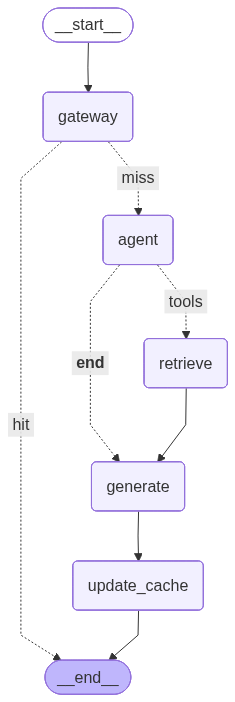

In [113]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

def compile_agent_graph(agent_node, tools):
    workflow = StateGraph(AgentState)
    
    # 1. Nodes: Cache Bouncer, LLM Brain, RAG Tools, Formatter, and Memory
    workflow.add_node("gateway", gateway_cache_node)
    workflow.add_node("agent", agent_node)
    workflow.add_node("retrieve", ToolNode(tools))
    workflow.add_node("generate", generate_recommendation)
    workflow.add_node("update_cache", update_cache_node)

    # 2. Logic: Entry point starts with the Semantic Cache check
    workflow.set_entry_point("gateway")
    
    # HIT -> End immediately | MISS -> Proceed to LLM
    workflow.add_conditional_edges(
        "gateway",
        lambda s: "hit" if s.get("cache_hit") else "miss",
        {"hit": END, "miss": "agent"}
    )
    
    # Standard Agentic RAG logic
    workflow.add_conditional_edges(
        "agent", 
        tools_condition, 
        {"tools": "retrieve", END: "generate"}
    )
    
    workflow.add_edge("retrieve", "generate")
    
    # Ensure every new generation is saved to the cache before exiting
    workflow.add_edge("generate", "update_cache")
    workflow.add_edge("update_cache", END)
    
    return workflow.compile()

# --- Build the specialized graphs ---
ciso_graph = compile_agent_graph(ciso_node, [similarity_search])
sre_graph  = compile_agent_graph(sre_node,  [similarity_search])
cto_graph  = compile_agent_graph(cto_node,  [similarity_search])
byte_graph = compile_agent_graph(byte_node, [similarity_search])

# Visualize the graph structure
display(Image(ciso_graph.get_graph().draw_mermaid_png()))

In [114]:
from langchain_core.messages import HumanMessage
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

# 1. Préparation du Fake Game State (Ticket AGT-1)
fake_state = {
    "company": {
        "cash": 4500,
        "turn": 3,
        "sector": "neobank",
        "adversary": "mafia",
        "compliance": 0.65,
        "reputation": 0.75,
        "insurance_active": False,
        "insurance_premium": 0,
        "breach_reported": False,
    },
    "nodes": [
        {"id": "n1", "name": "API Gateway",     "type": "entry",      "throughput": 7, "defense": 3, "visibility": 8, "cost": 4, "compliance_score": 6, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n2", "name": "Auth Service",     "type": "middleware", "throughput": 6, "defense": 5, "visibility": 6, "cost": 3, "compliance_score": 7, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n3", "name": "Payment Engine",   "type": "server",    "throughput": 8, "defense": 7, "visibility": 5, "cost": 6, "compliance_score": 8, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n4", "name": "Core DB",          "type": "database",  "throughput": 9, "defense": 8, "visibility": 4, "cost": 7, "compliance_score": 9, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n5", "name": "HR Portal",        "type": "human",     "throughput": 3, "defense": 2, "visibility": 7, "cost": 2, "compliance_score": 4, "compromised": True,  "locked": False, "offline": False, "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n6", "name": "Vendor KYC",       "type": "vendor",    "throughput": 5, "defense": 4, "visibility": 3, "cost": 5, "compliance_score": 5, "compromised": False, "locked": False, "offline": False, "isolated": False, "fogged": True,  "has_mfa": False, "monitored": False, "offline_turns": 0},
        {"id": "n7", "name": "Analytics Engine",  "type": "server",    "throughput": 6, "defense": 6, "visibility": 6, "cost": 3, "compliance_score": 6, "compromised": False, "locked": False, "offline": True,  "isolated": False, "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 1},
    ],
    "edges": [
        {"from": "n1", "to": "n2"},  # Gateway → Auth
        {"from": "n2", "to": "n3"},  # Auth → Payment
        {"from": "n3", "to": "n4"},  # Payment → Core DB
        {"from": "n1", "to": "n5"},  # Gateway → HR (entry → human)
        {"from": "n5", "to": "n2"},  # HR → Auth (lateral path)
        {"from": "n4", "to": "n6"},  # Core DB → Vendor KYC
        {"from": "n3", "to": "n7"},  # Payment → Analytics
    ],
    "flows": [
        {"name": "Card Payments",   "node_path": ["n1", "n2", "n3", "n4"], "base_revenue": 45, "is_active": True,  "current_revenue": 27},  # bottleneck n2 tp=6 → 45*6/10=27
        {"name": "P2P Transfers",   "node_path": ["n1", "n3", "n4"],       "base_revenue": 30, "is_active": True,  "current_revenue": 21},  # bottleneck n1 tp=7 → 30*7/10=21
        {"name": "KYC Onboarding",  "node_path": ["n1", "n2", "n6"],       "base_revenue": 15, "is_active": True,  "current_revenue":  7},  # bottleneck n6 tp=5 → 15*5/10=7.5→7
        {"name": "Analytics Reports","node_path": ["n3", "n7"],             "base_revenue": 10, "is_active": False, "current_revenue":  0},  # n7 offline
    ],
    "vulnerabilities": [
        {"node_id": "n1", "severity": 2, "known_by_player": True},
        {"node_id": "n2", "severity": 1, "known_by_player": False},
        {"node_id": "n6", "severity": 3, "known_by_player": False},
    ],
    "byte": {
        "byte_presence": {"n5": "compromised"},  # HR Portal already compromised
        "byte_ap": 2,
        "byte_active_ops": [],
    },
    "regulator": {
        "breach_timer": None,
        "deletion_requested": False,
    },
    "effects": [],
    "turn_log": [
        {"source": "byte",   "action": "B1", "target": "n5", "message": "Byte compromised HR Portal via phishing.", "visible_to_player": False},
        {"source": "system", "action": "B4", "target": "n7", "message": "Analytics Engine hit by DDoS. Offline for 2 turns.", "visible_to_player": True},
        {"source": "ciso",   "action": "S1", "target": "n1", "message": "Scan revealed vulnerability on API Gateway.", "visible_to_player": True},
    ],
}

inputs = {
    "messages": [HumanMessage(content="Analyze the state and provide your best recommendation.")],
    "game_state": fake_state
}


In [115]:
import copy

# 1. CLEAN THE CACHE (Force a fresh start for this test)
import shutil, os
# Re-initialize your cache_db here if necessary

# 2. PASS A: Save the "Secure" state
fake_state["nodes"][0]["compromised"] = False
print("--- RUN 1: SECURE STATE (LEARNING) ---")
ciso_graph.invoke({"game_state": fake_state, "active_role": "ciso"})

# 3. PASS B: Save the "Secure" state
fake_state["nodes"][0]["compromised"] = False
print("--- RUN 2: SECURE STATE (LEARNING) ---")
ciso_graph.invoke({"game_state": fake_state, "active_role": "ciso"})

# 4. PASS C: Test the "Breached" state
# We MUST use a deepcopy or change the value AFTER the first run
pwned_state = copy.deepcopy(fake_state)
pwned_state["nodes"][1]["compromised"] = True 
pwned_state["nodes"][0]["security_patch"] = "critical_missing"

print("\n--- RUN 3: BREACHED STATE (TESTING) ---")
res = ciso_graph.invoke({"game_state": pwned_state, "active_role": "ciso"})

print(f"\nFinal Result - Hit: {res.get('cache_hit')} | Score: {res.get('debug_score', 'check logs')}")

--- RUN 1: SECURE STATE (LEARNING) ---
DEBUG: Role: ciso | Key Hash: 8806190000939324466
DEBUG: Score: 1.0
🎯 Cache Hit pour le rôle ciso
--- RUN 2: SECURE STATE (LEARNING) ---
DEBUG: Role: ciso | Key Hash: 8806190000939324466
DEBUG: Score: 1.0
🎯 Cache Hit pour le rôle ciso

--- RUN 3: BREACHED STATE (TESTING) ---
DEBUG: Role: ciso | Key Hash: 1363190445924257938
DEBUG: Score: 1.0
🎯 Cache Hit pour le rôle ciso

Final Result - Hit: True | Score: check logs


In [116]:
# ============================================================
# EPIC 3 — Entity Generation (ENT-1 → ENT-4) - V1 procedural (Cancelled, switch to langgraph nodes)
# Reuses: vectorstore, embeddings, similarity_search from Epic 1
# ============================================================
import random

SECTORS = {
    "neobank":   {"cash": (4000, 6000), "adversary_weights": {"mafia": 0.5, "state": 0.2, "script_kiddie": 0.3}},
    "p2p":       {"cash": (3000, 5000), "adversary_weights": {"mafia": 0.3, "state": 0.1, "script_kiddie": 0.6}},
    "hft":       {"cash": (5000, 8000), "adversary_weights": {"mafia": 0.2, "state": 0.6, "script_kiddie": 0.2}},
    "payments":  {"cash": (3500, 5500), "adversary_weights": {"mafia": 0.4, "state": 0.3, "script_kiddie": 0.3}},
}

# --- ENT-1: Company Generator ---
def generate_company(sector: str = None) -> dict:
    sector = sector or random.choice(list(SECTORS.keys()))
    cfg = SECTORS[sector]
    adversary = random.choices(list(cfg["adversary_weights"].keys()), list(cfg["adversary_weights"].values()))[0]
    return {
        "cash": random.randint(*cfg["cash"]),
        "turn": 1,
        "sector": sector,
        "adversary": adversary,
        "compliance": 0.7,
        "reputation": 0.8,
        "insurance_active": False,
        "insurance_premium": 0,
        "breach_reported": False,
    }

# --- ENT-2: Infra Graph Generator (RAG-informed ranges) ---
NODE_TEMPLATES = {
    "neobank": [
        {"id": "n1", "name": "API Gateway",     "type": "entry",      "tp": (6,9), "def": (3,5), "vis": (7,9), "cost": (3,5), "comp": (5,7)},
        {"id": "n2", "name": "Auth Service",     "type": "middleware", "tp": (5,7), "def": (5,8), "vis": (5,7), "cost": (2,4), "comp": (7,9)},
        {"id": "n3", "name": "Payment Engine",   "type": "server",    "tp": (7,9), "def": (6,8), "vis": (4,6), "cost": (5,7), "comp": (7,9)},
        {"id": "n4", "name": "Core DB",          "type": "database",  "tp": (8,10),"def": (7,9), "vis": (3,5), "cost": (6,8), "comp": (8,10)},
        {"id": "n5", "name": "HR Portal",        "type": "human",     "tp": (2,4), "def": (1,3), "vis": (6,8), "cost": (1,3), "comp": (3,5)},
        {"id": "n6", "name": "Vendor KYC",       "type": "vendor",    "tp": (4,6), "def": (3,5), "vis": (2,4), "cost": (4,6), "comp": (4,6)},
        {"id": "n7", "name": "Fraud Detection",  "type": "server",    "tp": (5,7), "def": (5,7), "vis": (5,7), "cost": (3,5), "comp": (6,8)},
        {"id": "n8", "name": "Analytics Engine",  "type": "server",    "tp": (5,7), "def": (5,7), "vis": (5,7), "cost": (2,4), "comp": (5,7)},
    ],
    # P2P / HFT / Payments reuse neobank template with name swaps for MVP
    "p2p":      None,  # falls back to neobank
    "hft":      None,
    "payments": None,
}

EDGE_TEMPLATES = {
    "neobank": [
        ("n1", "n2"), ("n2", "n3"), ("n3", "n7"), ("n7", "n4"),  # main chain: GW→Auth→Pay→Fraud→DB
        ("n1", "n5"), ("n5", "n2"),  # lateral: GW→HR→Auth (phishing path)
        ("n4", "n6"),               # DB→Vendor
        ("n3", "n8"),               # Pay→Analytics
        ("n4", "n8"),               # DB→Analytics (Core DB 3+ edges: n3,n7,n6,n8)
    ],
}

FLOW_TEMPLATES = {
    "neobank": [
        {"name": "Card Payments",    "path": ["n1","n2","n3","n7","n4"], "revenue": (35,50)},
        {"name": "Subscriptions",    "path": ["n1","n2","n4"],           "revenue": (15,25)},
        {"name": "FX Transfers",     "path": ["n1","n3","n4"],           "revenue": (20,35)},
        {"name": "KYC Onboarding",   "path": ["n1","n2","n6"],           "revenue": (8,15)},
    ],
}

def make_node(template: dict) -> dict:
    return {
        "id": template["id"], "name": template["name"], "type": template["type"],
        "throughput": random.randint(*template["tp"]),
        "defense":    random.randint(*template["def"]),
        "visibility": random.randint(*template["vis"]),
        "cost":       random.randint(*template["cost"]),
        "compliance_score": random.randint(*template["comp"]),
        "compromised": False, "locked": False, "offline": False, "isolated": False,
        "fogged": False, "has_mfa": False, "monitored": False, "offline_turns": 0,
    }

def generate_infra(sector: str) -> tuple:
    templates = NODE_TEMPLATES.get(sector) or NODE_TEMPLATES["neobank"]
    nodes = [make_node(t) for t in templates]
    edges = [{"from": f, "to": t} for f, t in (EDGE_TEMPLATES.get(sector) or EDGE_TEMPLATES["neobank"])]
    return nodes, edges

# --- ENT-3: Revenue Flows ---
def generate_flows(sector: str, nodes: list) -> list:
    node_map = {n["id"]: n for n in nodes}
    flows = []
    for ft in (FLOW_TEMPLATES.get(sector) or FLOW_TEMPLATES["neobank"]):
        base = random.randint(*ft["revenue"])
        path_nodes = [node_map[nid] for nid in ft["path"]]
        active = all(not n["offline"] and not n["locked"] and not n["isolated"] for n in path_nodes)
        min_tp = min(n["throughput"] for n in path_nodes)
        flows.append({
            "name": ft["name"],
            "node_path": ft["path"],
            "base_revenue": base,
            "is_active": active,
            "current_revenue": int(base * min_tp / 10) if active else 0,
        })
    return flows

# --- ENT-4: Vulns + Fog + Byte Entry ---
def apply_vulns_fog_byte(nodes: list, adversary: str) -> tuple:
    # Vulns: 3-5 on non-Core-DB nodes
    eligible = [n for n in nodes if n["type"] != "database"]
    vuln_nodes = random.sample(eligible, min(random.randint(3, 5), len(eligible)))
    vulns = [{"node_id": n["id"], "severity": random.randint(1, 3), "known_by_player": False} for n in vuln_nodes]
    
    # Fog: 30-50% of nodes
    fog_count = random.randint(len(nodes) * 3 // 10, len(nodes) * 5 // 10)
    for n in random.sample(nodes, fog_count):
        n["fogged"] = True
    
    # Byte: starts outside, entry via 'entry' or 'human' nodes
    entries = [n["id"] for n in nodes if n["type"] in ("entry", "human")]
    byte_ap = 3 if adversary == "state" else 2
    
    return vulns, {"byte_presence": {}, "byte_ap": byte_ap, "byte_active_ops": []}, entries

# ============================================================
# GENERATE A FULL GAME STATE
# ============================================================
def generate_game_state(sector: str = None) -> dict:
    company = generate_company(sector)
    nodes, edges = generate_infra(company["sector"])
    flows = generate_flows(company["sector"], nodes)
    vulns, byte, entry_points = apply_vulns_fog_byte(nodes, company["adversary"])
    
    return {
        "company": company,
        "nodes": nodes,
        "edges": edges,
        "flows": flows,
        "vulnerabilities": vulns,
        "byte": byte,
        "regulator": {"breach_timer": None, "deletion_requested": False},
        "effects": [],
        "turn_log": [{"source": "system", "action": "INIT", "target": None, 
                       "message": f"New {company['sector']} generated. Adversary: {company['adversary']}. Entry points: {entry_points}",
                       "visible_to_player": True}],
    }

# --- TEST ---
state = generate_game_state()
c = state["company"]
print(f"🏢 {c['sector'].upper()} | Cash: {c['cash']}€K | Adversary: {c['adversary']}")
print(f"📊 Nodes: {len(state['nodes'])} | Edges: {len(state['edges'])} | Flows: {len(state['flows'])}")
print(f"🐛 Vulns: {len(state['vulnerabilities'])} | Fogged: {sum(1 for n in state['nodes'] if n['fogged'])}/{len(state['nodes'])}")
print(f"👹 Byte AP: {state['byte']['byte_ap']} | Entries: {[n['id'] for n in state['nodes'] if n['type'] in ('entry','human')]}")
print()
for f in state["flows"]:
    status = "✅" if f["is_active"] else "❌"
    print(f"  {status} {f['name']:20s} base={f['base_revenue']}€K  current={f['current_revenue']}€K  path={f['node_path']}")

🏢 HFT | Cash: 6903€K | Adversary: state
📊 Nodes: 8 | Edges: 9 | Flows: 4
🐛 Vulns: 4 | Fogged: 2/8
👹 Byte AP: 3 | Entries: ['n1', 'n5']

  ✅ Card Payments        base=45€K  current=22€K  path=['n1', 'n2', 'n3', 'n7', 'n4']
  ✅ Subscriptions        base=19€K  current=9€K  path=['n1', 'n2', 'n4']
  ✅ FX Transfers         base=28€K  current=22€K  path=['n1', 'n3', 'n4']
  ✅ KYC Onboarding       base=12€K  current=4€K  path=['n1', 'n2', 'n6']


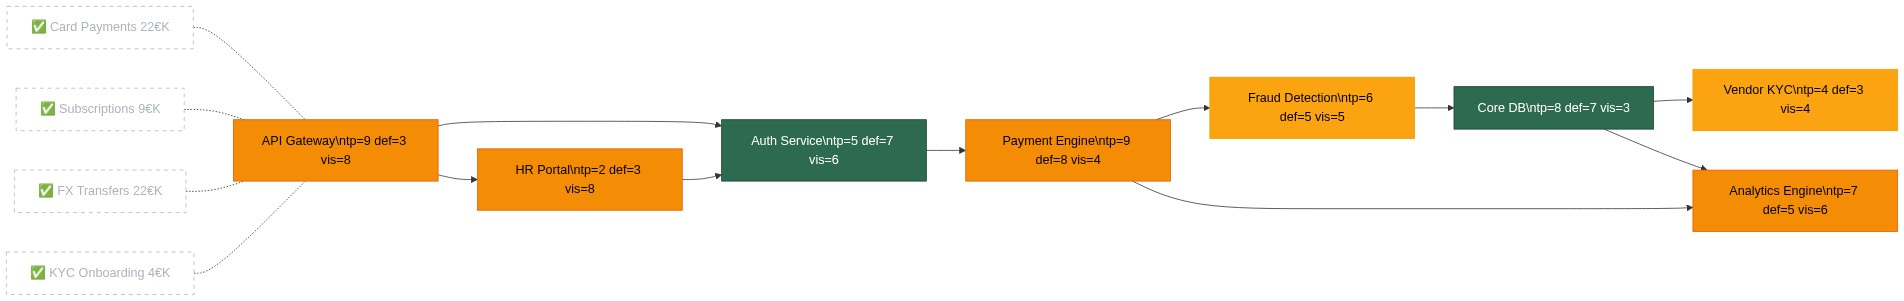

In [117]:
# --- MERMAID GRAPH DISPLAY ---
from IPython.display import Image, display
import base64, urllib.parse, httpx

def render_mermaid(state: dict) -> Image:
    nodes = state["nodes"]
    edges = state["edges"]
    flows = state["flows"]
    vulns = {v["node_id"] for v in state["vulnerabilities"]}
    fogged = {n["id"] for n in nodes if n["fogged"]}
    compromised = {n["id"] for n in nodes if n["compromised"]}
    offline = {n["id"] for n in nodes if n["offline"]}
    byte_nodes = set(state["byte"]["byte_presence"].keys())
    
    lines = ["graph LR"]
    
    # Node styling
    for n in nodes:
        label = f"{n['name']}\\ntp={n['throughput']} def={n['defense']} vis={n['visibility']}"
        nid = n["id"]
        if nid in compromised or nid in byte_nodes:
            lines.append(f'    {nid}["{label}"]:::compromised')
        elif nid in offline:
            lines.append(f'    {nid}["{label}"]:::offline')
        elif nid in fogged:
            lines.append(f'    {nid}["{label}"]:::fogged')
        elif nid in vulns:
            lines.append(f'    {nid}["{label}"]:::vulnerable')
        else:
            lines.append(f'    {nid}["{label}"]:::healthy')
    
    # Edges
    for e in edges:
        lines.append(f'    {e["from"]} --> {e["to"]}')
    
    # Flow highlights as subgraph labels
    for i, f in enumerate(flows):
        status = "✅" if f["is_active"] else "❌"
        rev = f["current_revenue"]
        lines.append(f'    F{i}["{status} {f["name"]} {rev}€K"]:::flow')
        lines.append(f'    F{i} -.- {f["node_path"][0]}')
    
    # Styles
    lines.append("    classDef healthy fill:#2d6a4f,stroke:#1b4332,color:#fff")
    lines.append("    classDef compromised fill:#d00000,stroke:#6a040f,color:#fff")
    lines.append("    classDef offline fill:#6c757d,stroke:#495057,color:#fff")
    lines.append("    classDef fogged fill:#fca311,stroke:#e5a100,color:#000")
    lines.append("    classDef vulnerable fill:#f48c06,stroke:#e85d04,color:#000")
    lines.append("    classDef flow fill:none,stroke:#adb5bd,stroke-dasharray:5,color:#adb5bd")
    
    mermaid_str = "\n".join(lines)
    
    # Render via mermaid.ink
    encoded = base64.urlsafe_b64encode(mermaid_str.encode("utf-8")).decode("ascii")
    url = f"https://mermaid.ink/img/{encoded}"
    resp = httpx.get(url, timeout=15)
    return Image(resp.content)

display(render_mermaid(state))

In [118]:
fintech_retriever = vectorstore.as_retriever(search_kwargs={'filter': {'agent': 'fintech'}, 'k': 3})
tech_retriever = vectorstore.as_retriever(search_kwargs={'filter': {'agent': 'techno'}, 'k': 10})

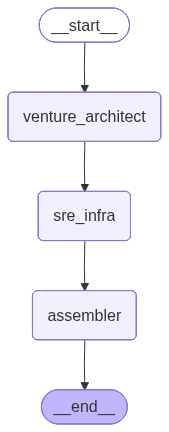

In [119]:
import json
import random
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables import RunnablePassthrough

# --- 1. SCHEMA DE L'ETAT ---
class GameCreationState(TypedDict):
    user_prompt: str
    company_data: Dict[str, Any]
    infra_data: Dict[str, Any]
    final_gamestate: Dict[str, Any]

llm = ChatOpenAI(model="gpt-4o", temperature=0.7)

# --- 2. AGENTS ---

def venture_architect_node(state: GameCreationState):
    """Agent 1 : Génère une startup avec un Product-Market Fit validé et du cash."""
    print("🚀 [Venture Architect] Génération d'une startup 'Seed-plus' avec du runway...")
    
    prompt = ChatPromptTemplate.from_template("""
    You are the Venture Architect. Your goal is to define a Fintech startup that is janky but functional.
    It should not be a total disaster, but a company that just raised a decent round and needs a CTO to clean up.

    CONTEXT: {context}
    PLAYER REQUEST: {input}

    RULES:
    - NAME: Creative startup name (e.g., CleanPay, TrashVault, Suds).
    - DESCRIPTION: Cynical but slightly optimistic. "We have customers, but the backend is a mystery."
    - INITIAL CASH: 4500-6000 €K (Plenty of runway to start).
    - FLOWS: 3-4 flows. Ensure they feel like they are actually providing value.

    OUTPUT FORMAT (JSON):
    {{
        "name": "Creative Name",
        "description": "Cynical but redeemable pitch",
        "sector": "neobank|p2p|hft|payments",
        "adversary": "script_kiddie|mafia|state",
        "cash": 5000,
        "flows": [
            {{ 
                "name": "Flow Name", 
                "description": "Monetization logic",
                "node_path_types": ["entry", "middleware", "database"], 
                "base_revenue": 60
            }}
        ]
    }}
    """)
    
    chain = ({"context": fintech_retriever, "input": RunnablePassthrough()} | prompt | llm | JsonOutputParser())
    result = chain.invoke(state["user_prompt"])
    return {"company_data": result}

def sre_infra_node(state: GameCreationState):
    """Agent 2 : Design une infra 'Legacy' mais stable. Moins de nodes bloqués au départ."""
    print("🛠️ [Lead SRE] Provisioning d'un cluster 'Legacy-Stable'...")
    
    tech_docs = tech_retriever.invoke("gateway database server middleware vendor human")
    tech_context = "\n".join([d.page_content for d in tech_docs])
    
    prompt = ChatPromptTemplate.from_template("""
    You are the Lead SRE. You are building an infra that has survived for 2 years. 
    It's built on legacy tech, but it's not currently collapsing.

    COMPANY SPECS: {specs}
    TECH DATABASE: {tech_context}

    RULES:
    - NODES: 7-9 nodes. Ensure at least 2 entry points (redundancy).
    - DESCRIPTIONS: SRE humor about "Old faithful" tech. "It's ugly, but it works."
    - STATS: Defense minimum 4. Visibility minimum 4. No "defense: 1" nodes.
    - INITIAL STATE: Max 1 node compromised. NO critical database should be 'locked' at turn 1.
    - VULNERABILITIES: 3-5 vulns, mostly severity 2-4 (fixable).

    OUTPUT FORMAT (JSON):
    {{
        "nodes": [
            {{ 
                "id": "n1", "name": "...", "type": "...", "description": "Relatable SRE text",
                "stats": {{ "throughput": 6, "defense": 5, "visibility": 5, "cost": 4, "compliance_score": 5 }}, 
                "tags": {{ "compromised": false, "locked": false, "offline": false, "fogged": true }}
            }}
        ],
        "edges": [{{ "from": "n1", "to": "n2" }}],
        "vulnerabilities": [{{ "node_id": "n1", "severity": 3, "description": "A lazy but fixable bug", "known_by_player": false }}]
    }}
    """)
    
    chain = (prompt | llm | JsonOutputParser())
    result = chain.invoke({"specs": json.dumps(state["company_data"]), "tech_context": tech_context})
    return {"infra_data": result}

def game_assembler_node(state: GameCreationState):
    """Agent 3 : Calibration pour assurer un profit positif au début."""
    print("🏁 [Assembler] Équilibrage budgétaire pour un départ serein...")
    
    comp = state["company_data"]
    infra = state["infra_data"]
    nodes = infra["nodes"]
    
    final_flows = []
    for f in comp["flows"]:
        path_ids = []
        for t in f["node_path_types"]:
            match = next((n["id"] for n in nodes if n["type"] == t and n["id"] not in path_ids), None)
            if not match: match = next((n["id"] for n in nodes if n["type"] == t), nodes[0]["id"])
            path_ids.append(match)
        
        tp_values = [next((n["stats"]["throughput"] for n in nodes if n["id"] == pid), 6) for pid in path_ids]
        tp_min = min(tp_values) if tp_values else 6
        
        # On s'assure que le flow est actif (pas de node locked/offline dans le path)
        is_active = all(not next(n["tags"]["locked"] or n["tags"]["offline"] for n in nodes if n["id"] == pid) for pid in path_ids)

        final_flows.append({
            "name": f["name"],
            "description": f["description"],
            "node_path": path_ids,
            "base_revenue": f["base_revenue"],
            "is_active": is_active,
            "current_revenue": int(f["base_revenue"] * tp_min / 10) if is_active else 0
        })

    game_state = {
        "company": {
            **comp,
            "turn": 1,
            "compliance": 0.7,
            "reputation": 0.85,
            "insurance_active": False,
            "insurance_premium": 0,
            "breach_reported": False
        },
        "nodes": [{**n, **n["stats"], **n["tags"]} for n in nodes],
        "edges": infra["edges"],
        "flows": final_flows,
        "vulnerabilities": infra["vulnerabilities"],
        "byte": {
            "byte_presence": {},
            "byte_ap": 2,
            "byte_active_ops": []
        },
        "regulator": {"breach_timer": None, "deletion_requested": False},
        "effects": [],
        "turn_log": [{"source": "system", "action": "init", "message": f"{comp['name']} is scaling. Infrastructure is messy but revenue is flowing."}]
    }
    
    return {"final_gamestate": game_state}

# --- 3. BÂTIR LE GRAPH ---
# (Architecture remains same as your previous working code)
builder = StateGraph(GameCreationState)
builder.add_node("venture_architect", venture_architect_node)
builder.add_node("sre_infra", sre_infra_node)
builder.add_node("assembler", game_assembler_node) # assembler remains as previously defined

builder.set_entry_point("venture_architect")
builder.add_edge("venture_architect", "sre_infra")
builder.add_edge("sre_infra", "assembler")
builder.add_edge("assembler", END)

game_generator = builder.compile()
display(Image(game_generator.get_graph().draw_mermaid_png()))

In [120]:
# --- 4. EXECUTION ---
# This prompt encourages mundane/cynical "real-world" chaos.
config = {
    "user_prompt": (
        "Generate a highly disruptive Fintech startup that tackles an incredibly "
        "boring and mundane industry (like dry-cleaning, trash collection, or corporate "
        "furniture leasing). The CTO is drowning in technical debt from 'quick hacks' "
        "and the company is currently being blackmailed by a professional adversary."
    )
}

result = game_generator.invoke(config)

print("--- GENERATED GAME STATE (Relatable Mode) ---")
print(json.dumps(result["final_gamestate"], indent=2))

🚀 [Venture Architect] Génération d'une startup 'Seed-plus' avec du runway...
🛠️ [Lead SRE] Provisioning d'un cluster 'Legacy-Stable'...
🏁 [Assembler] Équilibrage budgétaire pour un départ serein...
--- GENERATED GAME STATE (Relatable Mode) ---
{
  "company": {
    "name": "LeaseCoin",
    "description": "We've cracked the code on making corporate furniture leasing almost interesting. We have customers, but the backend is a mystery even to us.",
    "sector": "payments",
    "adversary": "script_kiddie",
    "cash": 5500,
    "flows": [
      {
        "name": "Instant Lease Payments",
        "description": "Enabling companies to instantly lease furniture with a single tap, while we take a small transaction fee.",
        "node_path_types": [
          "entry",
          "middleware",
          "database"
        ],
        "base_revenue": 100
      },
      {
        "name": "Furniture Tokenization",
        "description": "Tokenizing physical furniture into digital assets, allowing u

In [121]:
import json

# 1. RÉCUPÉRATION DU STATE GÉNÉRÉ
current_state = result["final_gamestate"]

# 2. CONFIGURATION DU TEST MULTI-AGENTS
agents_to_test = [
    ("🛡️ CISO", ciso_graph, "ciso"),
    ("⚙️ SRE",  sre_graph,  "sre"),
    ("💼 CTO",  cto_graph,  "cto"),
    ("👹 BYTE", byte_graph, "hacker")
]

print(f"=== ANALYSE DE CRISE : {current_state['company']['name'].upper()} ===")
print(f"Scenario: {current_state['company']['description']}\n")

# 3. EXÉCUTION D'UNE PASSE UNIQUE PAR AGENT
for agent_name, graph, role in agents_to_test:
    try:
        # Invocation du graphe (renvoie le dictionnaire d'état final)
        state_output = graph.invoke({
            "game_state": current_state, 
            "active_role": role
        })
        
        # LangGraph invoke peut renvoyer une liste ou un dict selon ta compilation
        # On s'assure de récupérer le dictionnaire d'état
        final_state = state_output[0] if isinstance(state_output, list) else state_output
        
        # 1. On récupère le dernier message AIMessage
        last_message = final_state["messages"][-1]
        
        # 2. On parse le contenu JSON du message
        recommendation = json.loads(last_message.content)
        
        # 3. Extraction propre des données
        act_id = recommendation.get("action_id", "??")
        title  = recommendation.get("action_label", "N/A")
        desc   = recommendation.get("action_description", "Aucune justification fournie.")
        target = recommendation.get("target", "Global")
        
        print(f"{agent_name} propose l'action [{act_id}] sur {target}")
        print(f"TITRE : {title}")
        print(f"DESCRIPTION : {desc}")
        print("-" * 60)
        
    except Exception as e:
        print(f"❌ Erreur avec l'agent {agent_name}: {e}")

=== ANALYSE DE CRISE : LEASECOIN ===
Scenario: We've cracked the code on making corporate furniture leasing almost interesting. We have customers, but the backend is a mystery even to us.

DEBUG: Role: ciso | Key Hash: -3187140879163773328
DEBUG: Score: 0.9125229716300964
💨 Cache Miss pour le rôle ciso
✅ Cache entry saved for role: ciso
🛡️ CISO propose l'action [S1+S3] sur Global
TITRE : Secure Nodes
DESCRIPTION : Implement advanced security protocols on nodes to mitigate risks.
------------------------------------------------------------
DEBUG: Role: sre | Key Hash: -1646327587882866410
DEBUG: Score: 0.908018171787262
💨 Cache Miss pour le rôle sre
✅ Cache entry saved for role: sre
⚙️ SRE propose l'action [E1] sur Global
TITRE : Optimize
DESCRIPTION : Boost throughput to improve revenue flow.
------------------------------------------------------------
DEBUG: Role: cto | Key Hash: -1367048930284907647
DEBUG: Score: 0.9043128490447998
💨 Cache Miss pour le rôle cto
✅ Cache entry saved fo